# Chapter 140 — Span

> **Prerequisites:** ch139 (Basis and Dimension), ch138 (Subspaces), ch127 (Linear Combination)  
> **You will learn:**
> - What the span of a set of vectors is and why it is always a subspace
> - How to determine whether a vector is in the span of a given set
> - How adding or removing vectors changes the span
> - The relationship between span, basis, and dimension
> - How span appears in practice in systems of equations and data science
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

The **span** of a set of vectors S = {**v₁**, **v₂**, ..., **vₖ**} is the set of all linear combinations of those vectors:

```
span(S) = {c₁v₁ + c₂v₂ + ... + cₖvₖ : c₁, c₂, ..., cₖ ∈ ℝ}
```

Span answers the question: *what territory can I reach if I'm allowed to walk in the directions given by the vectors in S, scaling and combining freely?*

Key facts:
- The span of any set of vectors is always a subspace *(verified in ch138)*.
- The span of the empty set is {**0**} (the trivial subspace).
- A set of vectors **spans** a space V if span(S) = V.
- A basis is exactly a spanning set that is also linearly independent — the minimal spanning set.

**Common misconceptions:**
- "Adding more vectors always increases the span." False — adding a vector already in the span leaves it unchanged. A dependent vector contributes nothing new.
- "The span of n vectors in ℝⁿ is ℝⁿ." False — if the vectors are linearly dependent, the span is a strict subspace of ℝⁿ.

---

## 2. Intuition & Mental Models

**Geometric model:** Think of span as reachability. Stand at the origin. Each vector in S is a direction you can travel. You can go 3 steps in direction **v₁**, then -2 steps in direction **v₂**, then 0.5 steps in **v₃** — any combination, any scale. The set of all positions you can reach is the span.

- One non-zero vector spans a line through the origin.
- Two non-parallel vectors in ℝ³ span a plane through the origin.
- Three linearly independent vectors in ℝ³ span all of ℝ³.

**Computational model:** Span is the image of a matrix. If A is the matrix whose columns are **v₁**, ..., **vₖ**, then:
```
span({v₁, ..., vₖ}) = {Ax : x ∈ ℝᵏ} = column space C(A)
```
The question "is **b** in the span?" becomes "does A**x** = **b** have a solution?" — a linear system, which we know how to solve. *(This will be formalized in ch160.)*

Recall from ch127 (Linear Combination): every element of the span is a linear combination. The span is the closure of S under linear combination — you cannot leave it by combining vectors already in it.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_13356\850510082.py:55: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13356\850510082.py:55: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13356\850510082.py:55: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13356\850510082.py:55: UserWarning: Glyph 8477 (\N{DOUBLE-STRUCK CAPITAL R}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missin

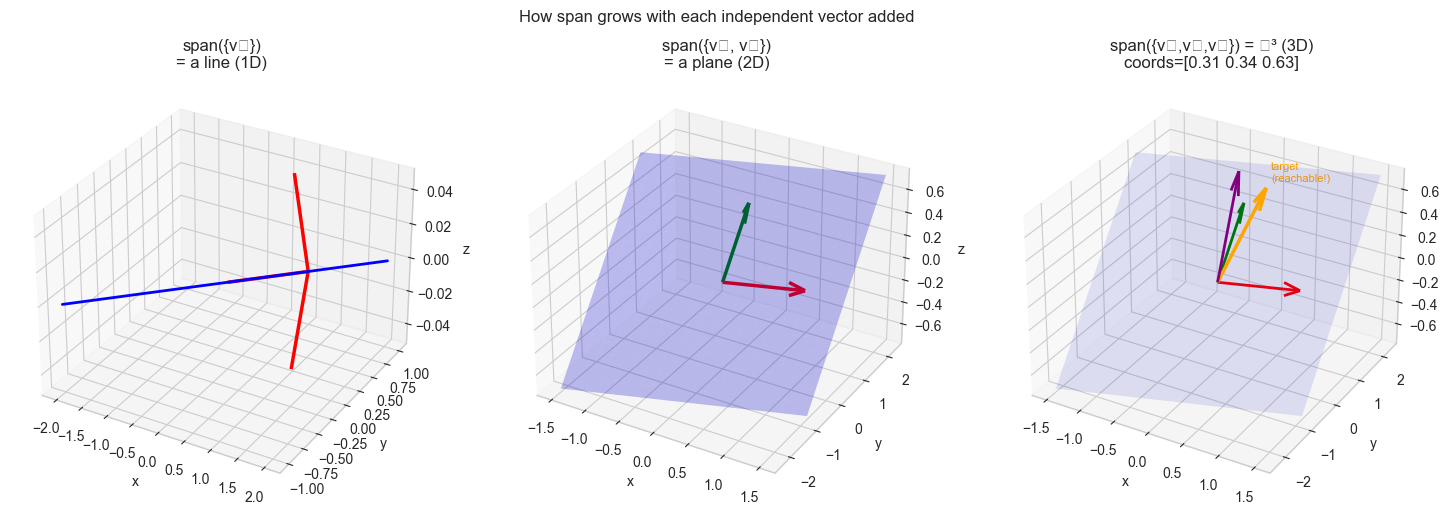

In [1]:
# --- Visualization: Span of 1, 2, and 3 vectors in R^3 ---
# Shows how span grows from a line -> plane -> all of R^3

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(15, 5))

v1 = np.array([1.0, 0.5, 0.0])
v2 = np.array([0.0, 1.0, 0.5])
v3 = np.array([0.3, 0.0, 1.0])

# --- Panel 1: span({v1}) — a line ---
ax1 = fig.add_subplot(131, projection='3d')
t = np.linspace(-2, 2, 100)
line = np.outer(t, v1)
ax1.plot(line[:, 0], line[:, 1], line[:, 2], 'b-', lw=2)
ax1.quiver(0, 0, 0, *v1, color='red', lw=2.5, arrow_length_ratio=0.2)
ax1.set_title('span({v₁})\n= a line (1D)')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

# --- Panel 2: span({v1, v2}) — a plane ---
ax2 = fig.add_subplot(132, projection='3d')
s_vals = np.linspace(-1.5, 1.5, 20)
t_vals = np.linspace(-1.5, 1.5, 20)
S, T = np.meshgrid(s_vals, t_vals)
X = S * v1[0] + T * v2[0]
Y = S * v1[1] + T * v2[1]
Z = S * v1[2] + T * v2[2]
ax2.plot_surface(X, Y, Z, alpha=0.25, color='blue')
ax2.quiver(0,0,0, *v1, color='red', lw=2.5, arrow_length_ratio=0.2)
ax2.quiver(0,0,0, *v2, color='green', lw=2.5, arrow_length_ratio=0.2)
ax2.set_title('span({v₁, v₂})\n= a plane (2D)')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

# --- Panel 3: span({v1, v2, v3}) — all of R^3 (if independent) ---
ax3 = fig.add_subplot(133, projection='3d')
# Show that we can reach a point off the v1-v2 plane
B = np.column_stack([v1, v2, v3])
target = np.array([0.5, 0.5, 0.8])
c = np.linalg.solve(B, target)

ax3.plot_surface(X, Y, Z, alpha=0.1, color='blue')  # v1-v2 plane for reference
ax3.quiver(0,0,0,*v1,color='red',lw=2,arrow_length_ratio=0.2)
ax3.quiver(0,0,0,*v2,color='green',lw=2,arrow_length_ratio=0.2)
ax3.quiver(0,0,0,*v3,color='purple',lw=2,arrow_length_ratio=0.2)
ax3.quiver(0,0,0,*target,color='orange',lw=2.5,arrow_length_ratio=0.2)
ax3.text(*target+0.05, f'target\n(reachable!)', fontsize=8, color='orange')
ax3.set_title(f'span({{v₁,v₂,v₃}}) = ℝ³ (3D)\ncoords={c.round(2)}')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')

plt.suptitle('How span grows with each independent vector added', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Definition:**  
For S = {**v₁**, ..., **vₖ**} ⊆ V:
```
span(S) = { Σᵢ cᵢ vᵢ  :  cᵢ ∈ ℝ }
```

**Theorem:** span(S) is a subspace of V.  
*Proof:* (i) Take all cᵢ = 0 → **0** ∈ span(S). (ii) Sum of two linear combinations is a linear combination. (iii) Scalar multiple of a linear combination is a linear combination. ∎

**Theorem:** span(S) is the smallest subspace containing S.  
*Meaning:* Any subspace W containing S must contain span(S).

**In terms of matrices:**
```
Let A = [v₁ | v₂ | ... | vₖ]  (columns are the vectors)

span({v₁,...,vₖ}) = C(A)  = {Ax : x ∈ ℝᵏ}

b ∈ span({v₁,...,vₖ})  ⟺  ∃x s.t. Ax = b  ⟺  b ∈ C(A)
```

**Span does not increase when a dependent vector is added:**
```
If vₖ₊₁ ∈ span({v₁,...,vₖ}), then span({v₁,...,vₖ,vₖ₊₁}) = span({v₁,...,vₖ})
```

**Dimension of the span:**
```
dim(span({v₁,...,vₖ})) = rank([v₁ | ... | vₖ])
```
The rank tells you how many of the vectors are actually contributing new directions. *(Rank is formalized in ch157.)*

---

## 5. Python Implementation

In [2]:
# --- Implementation: Span membership test and dimension ---

import numpy as np


def in_span(b, vectors, tol=1e-9):
    """
    Test whether b is in the span of the given vectors.

    Solves: A @ c = b (least squares) and checks the residual.

    Args:
        b: np.ndarray, shape (n,)
        vectors: list of np.ndarray, each shape (n,)
        tol: float — residual tolerance

    Returns:
        dict: {'in_span': bool, 'coefficients': np.ndarray or None, 'residual': float}
    """
    A = np.column_stack(vectors)
    c, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    residual = float(np.linalg.norm(A @ c - b))
    return {
        'in_span': residual < tol,
        'coefficients': c if residual < tol else None,
        'residual': residual
    }


def span_dimension(vectors, tol=1e-10):
    """
    Compute the dimension of span(vectors).

    Args:
        vectors: list of np.ndarray

    Returns:
        int — rank of the matrix formed by columns
    """
    A = np.column_stack(vectors)
    return np.linalg.matrix_rank(A, tol=tol)


def minimal_spanning_set(vectors, tol=1e-10):
    """
    Reduce a set of vectors to a minimal spanning set (a basis for their span).

    Uses column pivoting via QR decomposition to identify independent columns.

    Args:
        vectors: list of np.ndarray

    Returns:
        list of np.ndarray — a subset of the input that spans the same space
    """
    A = np.column_stack(vectors)
    # QR with column pivoting: first k columns (after pivoting) are independent
    Q, R, P = np.linalg.qr(A, mode='complete'), None, None
    # Use SVD to identify independent columns more robustly
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    rank = np.sum(s > tol)
    # Return U columns as the minimal spanning basis (orthonormalized)
    return [U[:, i] for i in range(rank)]


# --- Tests ---
print("=== Span membership tests ===")

v1 = np.array([1.0, 0.0, 0.0])
v2 = np.array([0.0, 1.0, 0.0])

# b in the xy-plane: should be in span
b1 = np.array([3.0, -2.0, 0.0])
# b off the xy-plane: should NOT be in span
b2 = np.array([1.0, 1.0, 1.0])

r1 = in_span(b1, [v1, v2])
r2 = in_span(b2, [v1, v2])

print(f"b1={b1} in span({{e1,e2}}): {r1['in_span']} (coeffs: {r1['coefficients']})")
print(f"b2={b2} in span({{e1,e2}}): {r2['in_span']} (residual: {r2['residual']:.4f})")

print()
print("=== Span dimension ===")
# Three vectors in R^3 — but two are parallel
redundant = [
    np.array([1.0, 2.0, 3.0]),
    np.array([2.0, 4.0, 6.0]),  # = 2 * first
    np.array([0.0, 1.0, 0.0])
]
print(f"3 vectors (one redundant): span dim = {span_dimension(redundant)}  (expected 2)")

independent = [
    np.array([1.0, 0.0, 0.0]),
    np.array([0.0, 1.0, 0.0]),
    np.array([0.0, 0.0, 1.0])
]
print(f"3 independent vectors: span dim = {span_dimension(independent)}  (expected 3)")

=== Span membership tests ===
b1=[ 3. -2.  0.] in span({e1,e2}): True (coeffs: [ 3. -2.])
b2=[1. 1. 1.] in span({e1,e2}): False (residual: 1.0000)

=== Span dimension ===
3 vectors (one redundant): span dim = 2  (expected 2)
3 independent vectors: span dim = 3  (expected 3)


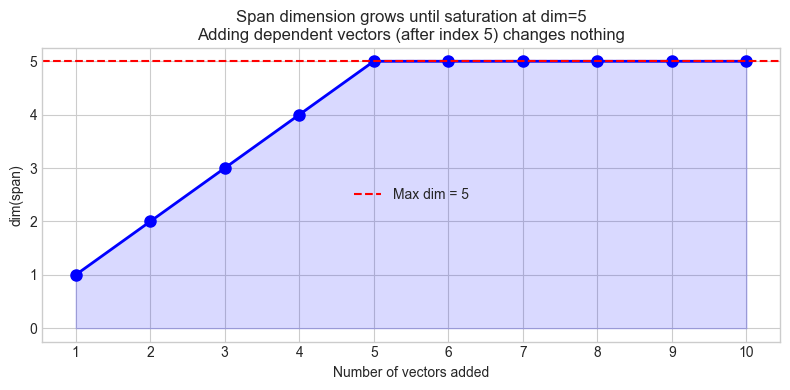

In [3]:
# --- Visualization: how span dimension changes as you add vectors ---

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

rng = np.random.default_rng(7)

AMBIENT_DIM = 5   # <-- try 3, 8, 10
MAX_VECTORS = 10  # number of vectors to add one by one

vectors = []
span_dims = []

for i in range(MAX_VECTORS):
    # Alternate between truly new vectors and dependent ones
    if i < AMBIENT_DIM:
        # Independent: random vector unlikely to be in current span
        v = rng.standard_normal(AMBIENT_DIM)
    else:
        # Dependent: linear combination of existing vectors
        coeffs = rng.standard_normal(len(vectors))
        v = sum(c * vec for c, vec in zip(coeffs, vectors))
    vectors.append(v)
    if len(vectors) == 1:
        dim = 1
    else:
        dim = span_dimension(vectors)
    span_dims.append(dim)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, MAX_VECTORS+1), span_dims, 'bo-', markersize=8, linewidth=2)
ax.axhline(AMBIENT_DIM, color='red', linestyle='--', label=f'Max dim = {AMBIENT_DIM}')
ax.fill_between(range(1, MAX_VECTORS+1), span_dims,
                 alpha=0.15, color='blue')
ax.set_xlabel('Number of vectors added')
ax.set_ylabel('dim(span)')
ax.set_title(f'Span dimension grows until saturation at dim={AMBIENT_DIM}\n'
              f'Adding dependent vectors (after index {AMBIENT_DIM}) changes nothing')
ax.set_xticks(range(1, MAX_VECTORS+1))
ax.legend()
plt.tight_layout()
plt.show()

---

## 6. Experiments

In [4]:
# --- Experiment 1: When does a set of vectors span R^n? ---
# Hypothesis: k vectors can span R^n only if k >= n AND they are independent.
# Try changing: n and k to observe the threshold.

import numpy as np

rng = np.random.default_rng(42)

n = 4       # dimension of ambient space  <-- modify
k_values = range(1, 8)  # number of vectors to try  <-- modify

print(f"Testing random vectors in R^{n}:")
print(f"{'k vectors':>12}  {'dim(span)':>10}  {'spans R^n?':>12}")

for k in k_values:
    A = rng.standard_normal((n, k))
    d = np.linalg.matrix_rank(A)
    spans_all = (d == n)
    print(f"  k={k:2d}          {d:10d}  {str(spans_all):>12}")

print(f"\nConclusion: need at least k={n} linearly independent vectors to span R^{n}.")
print(f"With k > {n}, extra vectors are redundant (rank still capped at {n}).")

Testing random vectors in R^4:
   k vectors   dim(span)    spans R^n?
  k= 1                   1         False
  k= 2                   2         False
  k= 3                   3         False
  k= 4                   4          True
  k= 5                   4          True
  k= 6                   4          True
  k= 7                   4          True

Conclusion: need at least k=4 linearly independent vectors to span R^4.
With k > 4, extra vectors are redundant (rank still capped at 4).


In [5]:
# --- Experiment 2: Span as the column space of a matrix ---
# Hypothesis: b in span({v1,...,vk}) iff Ax=b has a solution.
# Try changing: the target b and observe when solutions exist.

import numpy as np

# Matrix A: columns are the spanning vectors
A = np.array([
    [1, 0, 1],
    [0, 1, 1],
    [0, 0, 0]   # third row zero: rank < 3
], dtype=float)

print(f"Matrix A (columns = spanning vectors):")
print(A)
print(f"Rank = {np.linalg.matrix_rank(A)} (spans a 2D subspace of R^3)")
print()

# b vectors to test
targets = [
    (np.array([2.0, 3.0, 0.0]), "In column space (z=0)"),
    (np.array([1.0, 1.0, 1.0]), "NOT in column space (z=1)"),
    (np.array([0.5, -0.5, 0.0]), "In column space (z=0)"),  # <-- modify
]

for b, description in targets:
    c, residuals, rank, _ = np.linalg.lstsq(A, b, rcond=None)
    residual = np.linalg.norm(A @ c - b)
    in_cs = residual < 1e-9
    print(f"b = {b}  ({description})")
    print(f"  Residual: {residual:.2e}  ->  in span: {in_cs}")
    if in_cs:
        print(f"  Coefficients: {c.round(4)}")
    print()

Matrix A (columns = spanning vectors):
[[1. 0. 1.]
 [0. 1. 1.]
 [0. 0. 0.]]
Rank = 2 (spans a 2D subspace of R^3)

b = [2. 3. 0.]  (In column space (z=0))
  Residual: 4.44e-16  ->  in span: True
  Coefficients: [0.3333 1.3333 1.6667]

b = [1. 1. 1.]  (NOT in column space (z=1))
  Residual: 1.00e+00  ->  in span: False

b = [ 0.5 -0.5  0. ]  (In column space (z=0))
  Residual: 3.38e-16  ->  in span: True
  Coefficients: [ 0.5 -0.5 -0. ]



In [6]:
# --- Experiment 3: Removing vectors from a spanning set ---
# Hypothesis: A spanning set can be reduced to a basis without losing span.
# Approach: greedily remove vectors while maintaining the same span dimension.

import numpy as np

rng = np.random.default_rng(5)

N_DIM = 3  # ambient space  <-- modify
N_VECTORS = 7  # start with an overcomplete set  <-- modify

# Generate an overcomplete spanning set
base_vectors = [rng.standard_normal(N_DIM) for _ in range(N_DIM)]
extra_vectors = [sum(rng.random(N_DIM) * v for v in base_vectors)
                 for _ in range(N_VECTORS - N_DIM)]
all_vectors = base_vectors + extra_vectors

target_dim = np.linalg.matrix_rank(np.column_stack(all_vectors))
print(f"Starting with {len(all_vectors)} vectors, span dim = {target_dim}")

# Greedy reduction: try removing each vector; keep it removed if span dim unchanged
current_set = list(all_vectors)
removed = []

i = 0
while i < len(current_set):
    trial = current_set[:i] + current_set[i+1:]
    if len(trial) == 0:
        break
    d = np.linalg.matrix_rank(np.column_stack(trial))
    if d == target_dim:
        removed.append(i)
        current_set = trial  # remove it
    else:
        i += 1

final_dim = np.linalg.matrix_rank(np.column_stack(current_set))
print(f"After removal: {len(current_set)} vectors remain, span dim = {final_dim}")
print(f"This is a basis for the span: {len(current_set) == target_dim}")

Starting with 7 vectors, span dim = 3
After removal: 3 vectors remain, span dim = 3
This is a basis for the span: True


---

## 7. Exercises

**Easy 1.** For each set, state the dimension of the span and describe it geometrically:
- (a) {(1, 0, 0), (2, 0, 0)}
- (b) {(1, 0, 0), (0, 1, 0)}
- (c) {(1, 1, 0), (-1, 1, 0), (0, 0, 3)}

*(Expected: 1 (a line), 2 (the xy-plane), 3 (all of ℝ³))*

**Easy 2.** Write a function `does_span_rn(vectors, n)` that returns True if the vectors span ℝⁿ. Test it with several cases.

**Medium 1.** Given the vectors **v₁** = (1, 2, 3), **v₂** = (0, 1, 2), is **b** = (3, 7, 11) in span({**v₁**, **v₂**})? Find the coefficients or explain why not.

**Medium 2.** Given a 4×4 matrix A with rank 3, describe the span of its columns: what is its dimension, and in what space does it live? Now describe the span of the rows of A. Are they the same subspace? Same dimension?

**Hard.** Prove (computationally and in words): if span(S₁) = span(S₂) and both S₁ and S₂ are linearly independent, then |S₁| = |S₂| = dim(span). Write code to verify this for 50 random pairs of bases for the same subspace.

---

## 8. Mini Project

In [ ]:
# --- Mini Project: Feature Reachability Analyzer ---
#
# Problem: In ML, a model can only represent targets that lie in the span
# of its features (for linear models). Given a dataset of features and targets,
# determine which targets are representable (in the column space of the
# feature matrix) and which are not.
#
# This is the fundamental question of linear regression: is y reachable?

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(0)

# --- Dataset ---
# Features: x1 (income), x2 (age) — 2 features, N samples
N = 50
x1 = rng.uniform(20, 100, N)   # income (thousands)
x2 = rng.uniform(20, 65, N)    # age
X = np.column_stack([x1, x2])  # feature matrix: shape (N, 2)

# Three target vectors:
# y1: perfectly representable (linear combo of features)
y1 = 0.5*x1 - 0.3*x2 + 0.0   # exact linear combo — in span
# y2: representable with noise
y2 = 0.5*x1 - 0.3*x2 + rng.normal(0, 2, N)  # noisy — approximately in span
# y3: not representable (depends on x1^2)
y3 = 0.01 * x1**2 + rng.normal(0, 1, N)  # nonlinear — NOT in span of linear features

def fit_and_residual(X, y):
    """
    Fit y to span of X (least squares) and return residual norm.
    Large residual = y not in span(X).
    """
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ coeffs
    residual = np.linalg.norm(y - y_hat)
    r2 = 1 - np.var(y - y_hat) / np.var(y)
    return coeffs, y_hat, residual, r2

# --- TODO: run analysis for each target ---
targets = [('y1 (exact linear)', y1), ('y2 (linear + noise)', y2), ('y3 (nonlinear)', y3)]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, y) in zip(axes, targets):
    coeffs, y_hat, residual, r2 = fit_and_residual(X, y)
    ax.scatter(y, y_hat, alpha=0.5, s=20)
    mn, mx = min(y.min(), y_hat.min()), max(y.max(), y_hat.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual y')
    ax.set_ylabel('Predicted ŷ')
    ax.set_title(f'{name}\nR²={r2:.3f}  residual={residual:.2f}')
    ax.legend(fontsize=8)
    print(f"{name}: R²={r2:.4f}, residual norm={residual:.4f}")
    print(f"  Coefficients: {coeffs.round(4)}")
    in_span = r2 > 0.99
    print(f"  In span of X: {in_span}")
    print()

plt.suptitle('Feature Reachability: Is the target in span(X)?', fontsize=12)
plt.tight_layout()
plt.show()

---

## 9. Chapter Summary & Connections

**What was covered:**
- The span of a set S is the set of all linear combinations — every vector reachable from S.
- Span is always a subspace; it is the *smallest* subspace containing S.
- Adding a dependent vector to a spanning set does not change the span.
- Span dimension = rank of the matrix formed by the vectors.
- Testing span membership reduces to solving a linear system.

**Backward connection:** Span connects ch127 (Linear Combination) *(introduced in ch127)* with ch138–139 (Subspaces, Basis): the span of the basis vectors is the entire space, and that is precisely the definition of a basis — a minimal spanning set.

**Forward connections:**
- In ch141 (Linear Independence), we examine what makes a set of vectors *not* redundant — the condition that ensures each vector expands the span.
- This reappears in ch160 (Systems of Linear Equations): the question "does A**x** = **b** have a solution?" is exactly "is **b** in the column space (span of columns) of A?"
- In ch186 (PCA), the span of the top-k principal components is the k-dimensional subspace that captures the most variance in data — span becomes the language of dimensionality reduction.